## 06 System Stress Index: Compound Agricultural Risk on Tribal Lands
**Series:** Tribal Agriculture & Land Health in South Dakota  
**Author:** Lilly Jones, PhD  
**Primary Focus:** Oglala Lakota (Pine Ridge), Sicangu Lakota (Rosebud)  
**In Scope:** All South Dakota Tribal Nations  
**Inputs:** Notebooks 02 (PDSI), 03 (NDVI), 04 (NASS), 05 (NWIS)

## Purpose
Drought, vegetation stress, low livestock numbers, and poor water monitoring
coverage don't occur in isolation, they compound each other. A year of severe
drought (low PDSI) produces low NDVI; low NDVI indicates poor pasture condition;
poor pasture condition requires destocking; destocking reduces herd resilience
in the following year. The system stress concept captures this compounding.

This notebook synthesizes the indicator data from notebooks 02–05 into a
System Stress Index (SSI) for each South Dakota Tribal Nation. All inputs
are the tabular outputs already produced, no new downloads required.

## Index Components
| Component | Source | Weight | Direction |
|---|---|---|---|
| Drought stress (PDSI) | Notebook 02 | 40% | Low PDSI to high stress |
| Vegetation stress (NDVI) | Notebook 03 | 40% | Low NDVI to high stress |
| Monitoring gap | Notebook 05 | 20% | Coverage gap to high stress |

NASS cattle trends (notebook 04) are included as context but not in the
composite score, because NASS undercounts Tribal agriculture and livestock
declines may reflect management decisions rather than stress.

## What the SSI Is 
The SSI is an illustrative index based on publicly available proxy data.
It shows the **pattern** of compound stress over time and across Tribal Nations.
It is not a definitive measure of agricultural conditions on any specific Tribal
land that requires Tribal-collected field observations from the operational
pipeline. The SSI motivates Tribal data collection; it does not replace it.

## Research Questions
- Which years were highest compound stress on Pine Ridge and Rosebud?
- Is system stress trending upward over the MODIS era (2000–present)?
- Which Tribal Nations face the highest mean compound stress?
- How does the SSI compare to the Tribal water monitoring gap?

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime

import contextily as ctx
import geopandas as gpd
gpd.options.io_engine = "fiona"
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from shapely.validation import make_valid

from src.data import constants
from src.data.constants import (
    SD_TRIBES_ALL, SD_TRIBES_PRIMARY,
    CENSUS_NAME_MAP, CENSUS_TO_COMMON,
    PDSI_THRESHOLDS, NDVI_THRESHOLDS,
    CRS_GEOGRAPHIC, CRS_PROJECTED,
)
from src.indigenous.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

print(f"Repo root : {REPO_ROOT}")
print(f"Analysis run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Repo root : C:\Users\gekek\Documents\tas\Tribal_agricultural_science
Analysis run: 2026-08-20 12:37


In [2]:
# Print data acknowledgement at the top of every notebook TODO: Check!
print_data_acknowledgment(source_keys=["census_aiannh", "modis_ndvi"])


DATA SOVEREIGNTY ACKNOWLEDGMENT
This analysis uses data that describes Indigenous and Tribal lands,
communities, and agricultural and water systems. This project is
guided by three complementary data governance frameworks:

OCAP®  : Tribal Nations own, control, access, and possess data about
  their own communities and territories.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to
  communities, and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations to Tribal Nations that FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Practice for Provenance of Indigenous Peoples' Data.
  Establishes common parameter

## Configure

In [3]:
# SSI parameters 

# Analysis period = MODIS era (NDVI starts 2000)
SSI_START_YEAR = 2000
SSI_END_YEAR   = 2024

# Component weights (must sum to 1.0)
WEIGHTS = {
    "drought":    0.40,   # PDSI
    "vegetation": 0.40,   # NDVI
    "monitoring": 0.20,   # NWIS coverage gap
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-6, "Weights must sum to 1.0"

# PDSI growing season months (align with NDVI analysis)
GROWING_SEASON_MONTHS = [5, 6, 7, 8, 9]

# SSI categories
SSI_CATEGORIES = [
    (0.00, 0.25, "Low",      "#27AE60"),
    (0.25, 0.50, "Moderate", "#F1C40F"),
    (0.50, 0.75, "High",     "#E67E22"),
    (0.75, 1.00, "Critical", "#C0392B"),
]

print("SYSTEM STRESS INDEX CONFIGURATION")
print(f"  Analysis period : {SSI_START_YEAR}–{SSI_END_YEAR}")
print(f"  Growing season  : months {GROWING_SEASON_MONTHS}")
print("\nComponent weights:")
for k, v in WEIGHTS.items():
    print(f"  {k:<15}: {v:.0%}")

SYSTEM STRESS INDEX CONFIGURATION
  Analysis period : 2000–2024
  Growing season  : months [5, 6, 7, 8, 9]

Component weights:
  drought        : 40%
  vegetation     : 40%
  monitoring     : 20%


## Load Tribal Boundaries

In [4]:
# Tribal boundaries
GEOJSON_PATH = constants.OUTPUTS_DIR/"sd_tribal_land_base.geojson"
CACHE_PATH   = constants.CACHE_DIR/"tl_2023_us_aiannh.geojson"

if GEOJSON_PATH.exists():
    tribal_lands = gpd.read_file(GEOJSON_PATH)
    print(f"Loaded from notebook 01: {len(tribal_lands)} Tribal Nations")
elif CACHE_PATH.exists():
    all_aiannh = gpd.read_file(CACHE_PATH)
    census_names = list(CENSUS_NAME_MAP.values())
    tribal_lands = all_aiannh[all_aiannh["NAME"].isin(census_names)].copy()
    tribal_lands = tribal_lands.dissolve(by="NAME", as_index=False)
    tribal_lands["geometry"]    = tribal_lands.geometry.apply(make_valid)
    tribal_lands["common_name"] = tribal_lands["NAME"].map(CENSUS_TO_COMMON)
    tribal_lands["area_km2"]    = tribal_lands.to_crs(CRS_PROJECTED).geometry.area / 1e6
    tribal_lands["is_primary"]  = tribal_lands["common_name"].isin(SD_TRIBES_PRIMARY)
else:
    raise FileNotFoundError("Run notebook 01 first.")

print(tribal_lands[["common_name", "is_primary"]].to_string(index=False))

Loaded from notebook 01: 8 Tribal Nations
            common_name  is_primary
   Cheyenne River Sioux       False
       Crow Creek Sioux       False
 Flandreau Santee Sioux       False
Sisseton Wahpeton Oyate       False
      Lower Brule Sioux       False
          Oglala Lakota        True
          Rosebud Sioux        True
    Standing Rock Sioux       False


## Load Component Data from Previous Notebooks

In [5]:
# PDSI drought stress (from notebook 02)
PDSI_MONTHLY_PATH = constants.OUTPUTS_DIR/"sd_pdsi_monthly.csv"
PDSI_TRIBAL_PATH  = constants.OUTPUTS_DIR/"sd_tribal_drought_statistics.csv"

pdsi_available = PDSI_MONTHLY_PATH.exists()

if pdsi_available:
    pdsi_monthly = pd.read_csv(PDSI_MONTHLY_PATH, parse_dates=["date"])
    pdsi_monthly["year"]  = pdsi_monthly["date"].dt.year
    pdsi_monthly["month"] = pdsi_monthly["date"].dt.month

    # Growing season mean PDSI per division per year
    pdsi_gs = (
        pdsi_monthly[
            pdsi_monthly["month"].isin(GROWING_SEASON_MONTHS) &
            pdsi_monthly["year"].between(SSI_START_YEAR, SSI_END_YEAR)
        ]
        .groupby(["division", "year"])["pdsi"]
        .mean()
        .reset_index()
        .rename(columns={"pdsi": "pdsi_gs_mean"})
    )

    # Tribal drought stats (contains dominant_division mapping)
    if PDSI_TRIBAL_PATH.exists():
        tribal_drought = pd.read_csv(PDSI_TRIBAL_PATH)
        # Merge climate division to Tribal lands for annual PDSI
        tribe_div = tribal_drought[["common_name", "dominant_division"]].dropna().drop_duplicates()
        pdsi_tribal_annual = pdsi_gs.merge(
            tribe_div.rename(columns={"dominant_division": "division"}),
            on="division",
        )
        print(f"PDSI loaded: {len(pdsi_tribal_annual):,} Tribe-year records")
    else:
        # No tribal-division mapping: use mean across all SD divisions
        pdsi_all_mean = pdsi_gs.groupby("year")["pdsi_gs_mean"].mean().reset_index()
        pdsi_tribal_annual = pd.DataFrame()
        for name in tribal_lands["common_name"]:
            tmp = pdsi_all_mean.copy()
            tmp["common_name"] = name
            pdsi_tribal_annual = pd.concat([pdsi_tribal_annual, tmp], ignore_index=True)
        print(f"PDSI loaded (SD mean: run notebook 02 for Tribal-specific values)")
else:
    print("PDSI data not found. Run notebook 02 first.")
    print("  Expected: outputs/sd_pdsi_monthly.csv")
    pdsi_tribal_annual = pd.DataFrame()

PDSI loaded: 200 Tribe-year records


In [6]:
# NDVI vegetation stress (from notebook 03)
NDVI_ANNUAL_PATH = constants.OUTPUTS_DIR/"sd_tribal_ndvi_annual.csv"

ndvi_available = NDVI_ANNUAL_PATH.exists()

if ndvi_available:
    ndvi_annual = pd.read_csv(NDVI_ANNUAL_PATH)
    ndvi_annual = ndvi_annual[
        ndvi_annual["year"].between(SSI_START_YEAR, SSI_END_YEAR)
    ][["common_name", "year", "ndvi_mean"]].copy()
    print(f"NDVI loaded: {len(ndvi_annual):,} Tribe-year records")
else:
    print("NDVI data not found. Run notebook 03 first.")
    print("  Expected: outputs/sd_tribal_ndvi_annual.csv")
    ndvi_annual = pd.DataFrame()

NDVI data not found. Run notebook 03 first.
  Expected: outputs/sd_tribal_ndvi_annual.csv


In [7]:
# Monitoring gap (from notebook 05)
COVERAGE_PATH = constants.OUTPUTS_DIR/"groundwater_coverage_by_tribe.csv"

coverage_available = COVERAGE_PATH.exists()

if coverage_available:
    coverage_df = pd.read_csv(COVERAGE_PATH)
    # Normalize nearest_well_km to 0–1 stress score
    # 0 km to 0 stress; 100+ km to 1.0 stress
    coverage_df["monitoring_stress"] = (
        coverage_df["nearest_well_km"].clip(upper=100) / 100
    ).round(3)
    print(f"Coverage loaded: {len(coverage_df)} Tribal Nations")
    print(coverage_df[["common_name", "nearest_well_km", "monitoring_stress"]].to_string(index=False))
else:
    print("Coverage data not found. Run notebook 05 first.")
    print("  Expected: outputs/groundwater_coverage_by_tribe.csv")
    # Missing monitoring data remains unknown; it is never treated as neutral.
    coverage_df = tribal_lands[["common_name"]].copy()
    coverage_df["monitoring_stress"] = np.nan
    coverage_df["nearest_well_km"]   = np.nan

Coverage loaded: 8 Tribal Nations
            common_name  nearest_well_km  monitoring_stress
   Cheyenne River Sioux              1.8              0.018
       Crow Creek Sioux              5.7              0.057
 Flandreau Santee Sioux              0.7              0.007
Sisseton Wahpeton Oyate              0.4              0.004
      Lower Brule Sioux              2.1              0.021
          Oglala Lakota              0.8              0.008
          Rosebud Sioux              0.6              0.006
    Standing Rock Sioux              0.4              0.004


In [8]:
# NASS cattle trend (from notebook 04)
NASS_PATH = constants.OUTPUTS_DIR/"nass_tribal_ag_summary.csv"

if NASS_PATH.exists():
    nass_df = pd.read_csv(NASS_PATH)
    cattle_summary = nass_df[nass_df["label"] == "Cattle & Calves"][
        ["common_name", "mean_value", "pct_missing"]
    ].copy()
    print(f"NASS cattle context loaded: {len(cattle_summary)} Tribal Nations")
else:
    cattle_summary = pd.DataFrame()
    print("NASS data not found: cattle context will be omitted from visualizations.")

NASS data not found: cattle context will be omitted from visualizations.


## Build System Stress Index (SSI)

In [9]:
# Normalize components to 0–1 stress scale 
# Convention: 0 = no stress, 1 = maximum stress
# PDSI: lower (more negative) = higher drought stress
# NDVI: lower = more vegetation stress
# Monitoring gap: already normalized 0–1 in previous cell

def normalize_series(s: pd.Series, invert: bool = False) -> pd.Series:
    """
    Min-max normalize a series to [0, 1].
    invert=True means low raw values to high stress (used for PDSI and NDVI).
    """
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(0.5, index=s.index)
    normed = (s - mn) / (mx - mn)
    return (1 - normed) if invert else normed


# Annual stress components per Tribe
# Build annual panel: one row per (Tribe, year)

all_tribes = tribal_lands["common_name"].tolist()
years      = list(range(SSI_START_YEAR, SSI_END_YEAR + 1))

panel = pd.DataFrame(
    [(t, y) for t in all_tribes for y in years],
    columns=["common_name", "year"],
)

# Merge PDSI
if not pdsi_tribal_annual.empty:
    panel = panel.merge(
        pdsi_tribal_annual[["common_name", "year", "pdsi_gs_mean"]],
        on=["common_name", "year"], how="left",
    )
else:
    panel["pdsi_gs_mean"] = np.nan

# Merge NDVI
if not ndvi_annual.empty:
    panel = panel.merge(
        ndvi_annual[["common_name", "year", "ndvi_mean"]],
        on=["common_name", "year"], how="left",
    )
else:
    panel["ndvi_mean"] = np.nan

# Merge monitoring gap (static/same every year)
panel = panel.merge(
    coverage_df[["common_name", "monitoring_stress"]],
    on="common_name", how="left",
)

# Normalize components
panel["drought_stress"]    = normalize_series(panel["pdsi_gs_mean"],  invert=True)
panel["vegetation_stress"] = normalize_series(panel["ndvi_mean"],     invert=True)
# monitoring_stress already 0–1

# Composite SSI: weighted average of available components
def compute_ssi(row):
    components = {
        "drought":    (row.get("drought_stress"),    WEIGHTS["drought"]),
        "vegetation": (row.get("vegetation_stress"), WEIGHTS["vegetation"]),
        "monitoring": (row.get("monitoring_stress"), WEIGHTS["monitoring"]),
    }
    total_weight = 0
    total_score  = 0
    for name, (val, weight) in components.items():
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            total_score  += val * weight
            total_weight += weight
    return round(total_score / total_weight, 3) if total_weight > 0 else np.nan

panel["ssi"] = panel.apply(compute_ssi, axis=1)

# SSI category
def ssi_category(ssi):
    if pd.isna(ssi): return "No data"
    for lo, hi, cat, _ in SSI_CATEGORIES:
        if lo <= ssi < hi: return cat
    return "Critical"  # catches exactly 1.0

panel["ssi_category"] = panel["ssi"].apply(ssi_category)
panel["is_primary"]   = panel["common_name"].isin(SD_TRIBES_PRIMARY)

print(f"System Stress Index panel: {len(panel):,} Tribe-year records")
print(f"\nMissing data rates:")
for col in ["drought_stress", "vegetation_stress", "ssi"]:
    pct = panel[col].isna().mean() * 100
    print(f"  {col:<22}: {pct:.1f}% missing")

System Stress Index panel: 200 Tribe-year records

Missing data rates:
  drought_stress        : 0.0% missing
  vegetation_stress     : 100.0% missing
  ssi                   : 0.0% missing


In [10]:
# Summary statistics 
ssi_summary = (
    panel.dropna(subset=["ssi"])
    .groupby("common_name")
    .agg(
        mean_ssi=("ssi", "mean"),
        max_ssi=("ssi",  "max"),
        high_stress_years=("ssi", lambda x: (x >= 0.50).sum()),
        critical_years=("ssi",    lambda x: (x >= 0.75).sum()),
    )
    .round(3)
    .reset_index()
)
ssi_summary["is_primary"] = ssi_summary["common_name"].isin(SD_TRIBES_PRIMARY)

print("SYSTEM STRESS INDEX SUMMARY")
print(f"({SSI_START_YEAR}–{SSI_END_YEAR})")
print(
    ssi_summary[
        ["common_name", "mean_ssi", "max_ssi",
         "high_stress_years", "critical_years"]
    ]
    .sort_values("mean_ssi", ascending=False)
    .to_string(index=False)
)

# Highest stress years for all Tribes combined
print("\nHighest SSI years (mean across all Tribes):")
top_years = (
    panel.dropna(subset=["ssi"])
    .groupby("year")["ssi"]
    .mean().round(3)
    .sort_values(ascending=False)
    .head(5)
)
for yr, val in top_years.items():
    print(f"  {yr}: mean SSI = {val:.3f}")

SYSTEM STRESS INDEX SUMMARY
(2000–2024)
            common_name  mean_ssi  max_ssi  high_stress_years  critical_years
          Oglala Lakota     0.377    0.669                  9               0
          Rosebud Sioux     0.367    0.625                  7               0
       Crow Creek Sioux     0.352    0.626                  6               0
   Cheyenne River Sioux     0.344    0.645                  5               0
Sisseton Wahpeton Oyate     0.344    0.565                  2               0
      Lower Brule Sioux     0.340    0.614                  5               0
    Standing Rock Sioux     0.339    0.641                  5               0
 Flandreau Santee Sioux     0.337    0.557                  5               0

Highest SSI years (mean across all Tribes):
  2002: mean SSI = 0.608
  2012: mean SSI = 0.586
  2003: mean SSI = 0.551
  2021: mean SSI = 0.533
  2006: mean SSI = 0.528


In [11]:
# Trend analysis 
trend_records = []
for name, grp in panel.dropna(subset=["ssi"]).groupby("common_name"):
    grp = grp.sort_values("year")
    if len(grp) < 5:
        continue
    slope, _, _, _ = stats.theilslopes(grp["ssi"], grp["year"])
    _, _, _, p, _  = stats.linregress(grp["year"], grp["ssi"])
    trend_records.append({
        "common_name":      name,
        "slope_per_decade": round(slope * 10, 3),
        "p_value":          round(p, 3),
        "significant":      p < 0.05,
        "direction":        "Worsening" if slope > 0 else "Improving/Stable",
        "is_primary":       name in SD_TRIBES_PRIMARY,
    })

ssi_trend_df = pd.DataFrame(trend_records)

print("SSI TREND ANALYSIS (Theil-Sen slope)")
print("=" * 60)
print(
    ssi_trend_df[
        ["common_name", "slope_per_decade", "direction", "p_value", "significant"]
    ]
    .sort_values("slope_per_decade", ascending=False)
    .to_string(index=False)
)

SSI TREND ANALYSIS (Theil-Sen slope)
            common_name  slope_per_decade        direction  p_value  significant
Sisseton Wahpeton Oyate             0.036        Worsening    0.513        False
 Flandreau Santee Sioux            -0.038 Improving/Stable    0.310        False
    Standing Rock Sioux            -0.048 Improving/Stable    0.247        False
   Cheyenne River Sioux            -0.048 Improving/Stable    0.246        False
      Lower Brule Sioux            -0.055 Improving/Stable    0.253        False
       Crow Creek Sioux            -0.055 Improving/Stable    0.253        False
          Oglala Lakota            -0.056 Improving/Stable    0.407        False
          Rosebud Sioux            -0.080 Improving/Stable    0.116        False


## Visualizations

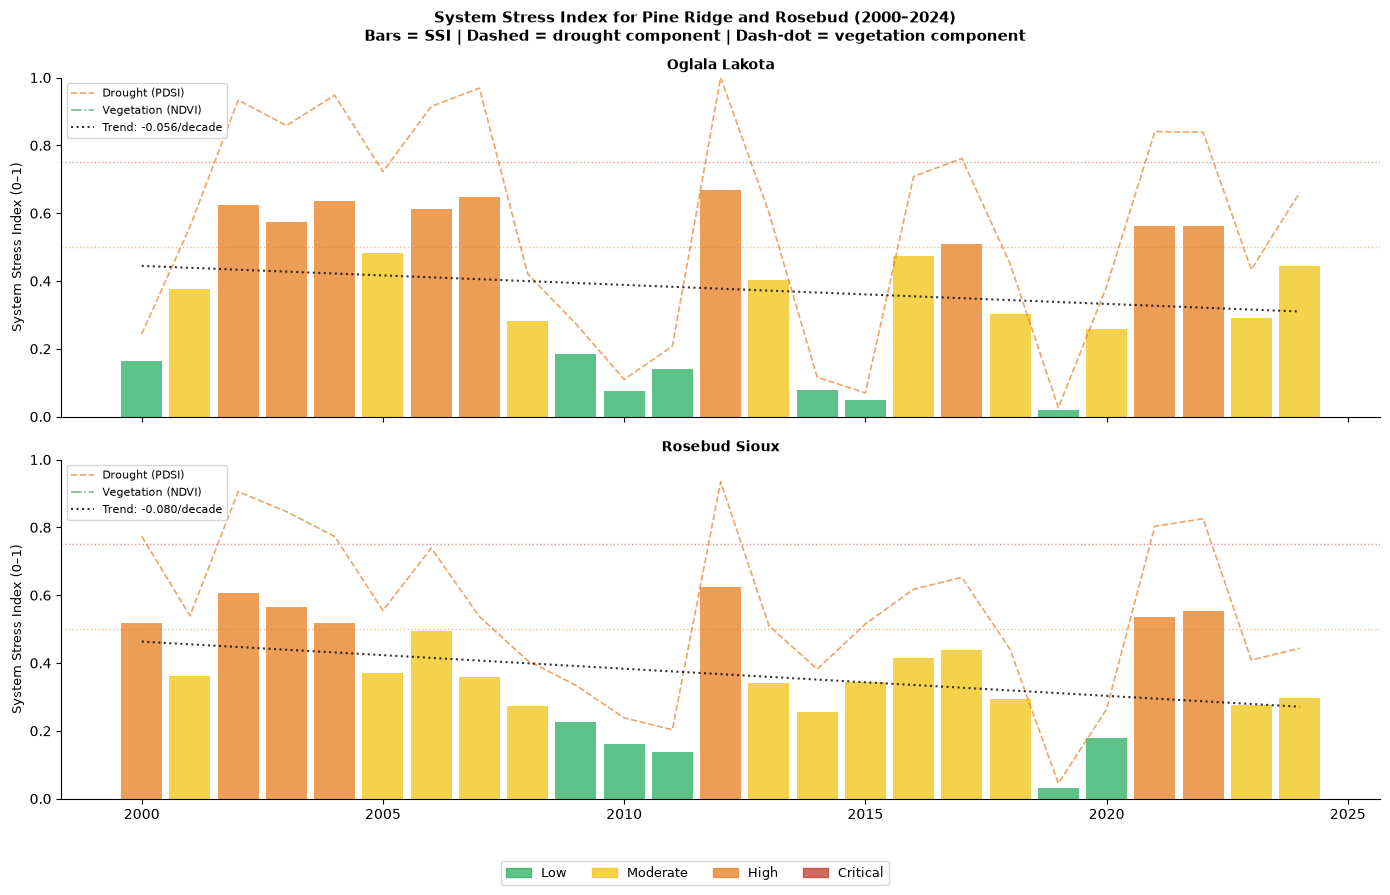

In [12]:
# Time series: SSI for Pine Ridge and Rosebud 
TRIBE_COLORS = {
    "Oglala Lakota": "#C0392B",
    "Rosebud Sioux": "#1A5276",
}
CAT_COLORS = dict((cat, col) for _, _, cat, col in SSI_CATEGORIES)

primary_panel = panel[panel["is_primary"]].sort_values(["common_name", "year"])

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, name in zip(axes, SD_TRIBES_PRIMARY):
    grp   = primary_panel[primary_panel["common_name"] == name].copy()
    color = TRIBE_COLORS.get(name, "gray")

    # SSI as filled area, colored by category
    for _, _, cat, cat_color in SSI_CATEGORIES:
        mask = grp["ssi_category"] == cat
        if mask.any():
            ax.bar(
                grp[mask]["year"], grp[mask]["ssi"],
                color=cat_color, alpha=0.75, width=0.85,
            )

    # Component lines
    if "drought_stress" in grp.columns:
        ax.plot(grp["year"], grp["drought_stress"],
                color="#E67E22", linewidth=1.2, linestyle="--",
                alpha=0.7, label="Drought (PDSI)")
    if "vegetation_stress" in grp.columns:
        ax.plot(grp["year"], grp["vegetation_stress"],
                color="#27AE60", linewidth=1.2, linestyle="-.",
                alpha=0.7, label="Vegetation (NDVI)")

    # Trend
    tr = ssi_trend_df[ssi_trend_df["common_name"] == name]
    if not tr.empty and not grp["ssi"].isna().all():
        valid = grp.dropna(subset=["ssi"])
        slope = tr["slope_per_decade"].iloc[0] / 10
        yrs   = valid["year"].values
        trend = slope * (yrs - yrs.mean()) + valid["ssi"].mean()
        ax.plot(yrs, trend, color="black", linewidth=1.5,
                linestyle=":", alpha=0.8,
                label=f"Trend: {tr['slope_per_decade'].iloc[0]:+.3f}/decade")

    # Horizontal risk lines
    for threshold, label, tcolor in [
        (0.50, "High risk",    "#E67E22"),
        (0.75, "Critical risk", "#C0392B"),
    ]:
        ax.axhline(threshold, color=tcolor, linestyle=":",
                   alpha=0.5, linewidth=1)

    ax.set_ylim(0, 1)
    ax.set_ylabel("System Stress Index (0–1)", fontsize=9)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper left")
    sns.despine(ax=ax)

fig.legend(
    handles=[
        mpatches.Patch(color=col, label=cat, alpha=0.75)
        for _, _, cat, col in SSI_CATEGORIES
    ],
    loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, 0),
)
plt.suptitle(
    f"System Stress Index for Pine Ridge and Rosebud ({SSI_START_YEAR}–{SSI_END_YEAR})\n"
    "Bars = SSI | Dashed = drought component | Dash-dot = vegetation component",
    fontsize=11, fontweight="bold",
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
try:
    fig_dir = constants.OUTPUTS_DIR / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_dir / "06_ssi_time_series_primary.png", dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

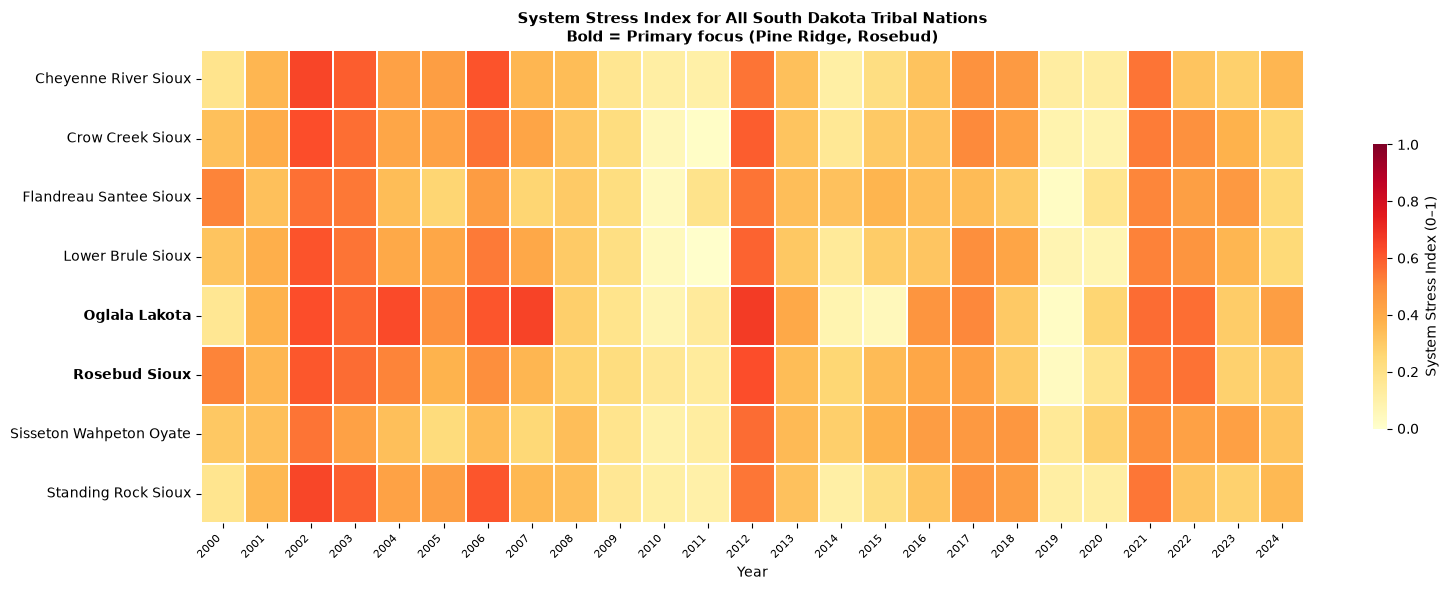

In [13]:
# Heatmap: SSI by Tribe and Year
ssi_pivot = panel.pivot(index="common_name", columns="year", values="ssi")

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    ssi_pivot,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    ax=ax,
    linewidths=0.3,
    cbar_kws={"label": "System Stress Index (0–1)", "shrink": 0.6},
)
# Bold primary Tribe row labels
for label in ax.get_yticklabels():
    if label.get_text() in SD_TRIBES_PRIMARY:
        label.set_fontweight("bold")

ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("")
ax.set_title(
    "System Stress Index for All South Dakota Tribal Nations\n"
    "Bold = Primary focus (Pine Ridge, Rosebud)",
    fontsize=11, fontweight="bold",
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
try:
    fig.savefig(fig_dir/"06_ssi_heatmap.png", dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

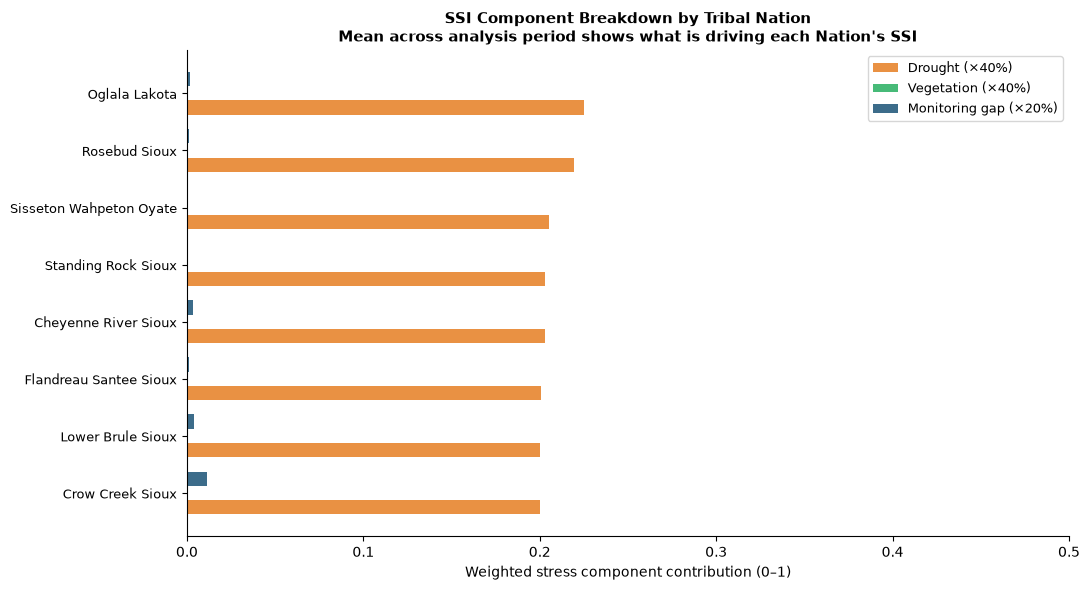

In [14]:
# SSI component breakdown: mean across years
component_means = (
    panel.dropna(subset=["ssi"])
    .groupby("common_name")[["drought_stress", "vegetation_stress", "monitoring_stress"]]
    .mean()
    .round(3)
    .reset_index()
    .sort_values("drought_stress", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 6))
x    = np.arange(len(component_means))
w    = 0.25

ax.barh(x - w, component_means["drought_stress"]    * WEIGHTS["drought"],
        w, color="#E67E22", alpha=0.85, label=f"Drought (×{WEIGHTS['drought']:.0%})")
ax.barh(x,     component_means["vegetation_stress"] * WEIGHTS["vegetation"],
        w, color="#27AE60", alpha=0.85, label=f"Vegetation (×{WEIGHTS['vegetation']:.0%})")
ax.barh(x + w, component_means["monitoring_stress"] * WEIGHTS["monitoring"],
        w, color="#1A5276", alpha=0.85, label=f"Monitoring gap (×{WEIGHTS['monitoring']:.0%})")

ax.set_yticks(x)
ax.set_yticklabels(component_means["common_name"], fontsize=9)
ax.set_xlabel("Weighted stress component contribution (0–1)", fontsize=10)
ax.set_title(
    "SSI Component Breakdown by Tribal Nation\n"
    "Mean across analysis period shows what is driving each Nation's SSI",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
ax.set_xlim(0, 0.5)
sns.despine(ax=ax)
plt.tight_layout()
try:
    fig.savefig(fig_dir / "06_ssi_component_breakdown.png", dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

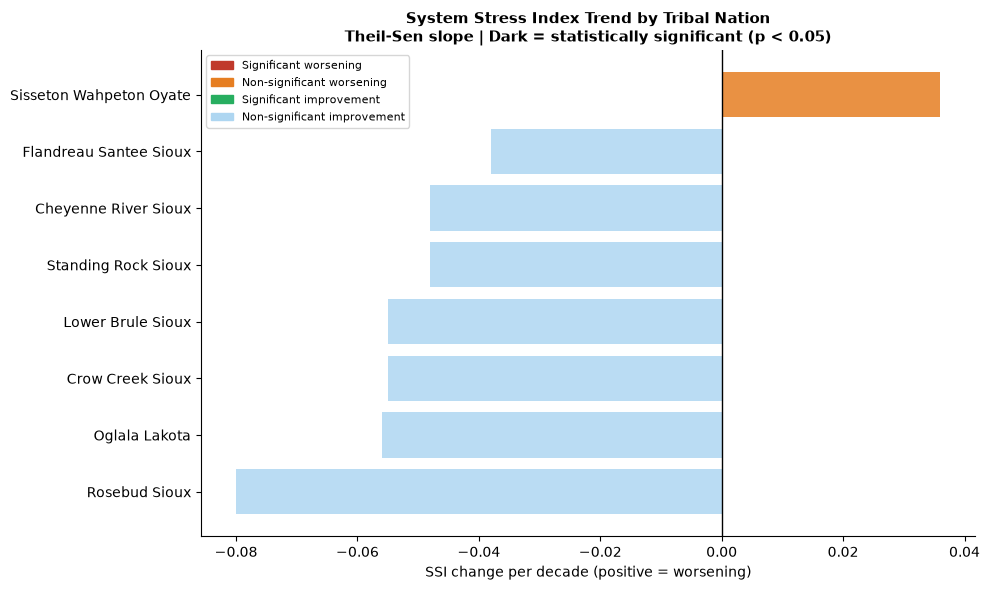

In [15]:
# SSI trend summary 
if not ssi_trend_df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    s = ssi_trend_df.sort_values("slope_per_decade", ascending=True)
    colors = [
        "#C0392B" if (d == "Worsening" and sig)
        else "#E67E22" if d == "Worsening"
        else "#27AE60" if sig
        else "#AED6F1"
        for d, sig in zip(s["direction"], s["significant"])
    ]
    ax.barh(s["common_name"], s["slope_per_decade"], color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("SSI change per decade (positive = worsening)", fontsize=10)
    ax.set_title(
        "System Stress Index Trend by Tribal Nation\n"
        "Theil-Sen slope | Dark = statistically significant (p < 0.05)",
        fontsize=11, fontweight="bold",
    )
    ax.legend(
        handles=[
            mpatches.Patch(color="#C0392B", label="Significant worsening"),
            mpatches.Patch(color="#E67E22", label="Non-significant worsening"),
            mpatches.Patch(color="#27AE60", label="Significant improvement"),
            mpatches.Patch(color="#AED6F1", label="Non-significant improvement"),
        ],
        fontsize=8,
    )
    sns.despine(ax=ax)
    plt.tight_layout()
    try:
        fig.savefig(fig_dir / "06_ssi_trend.png", dpi=150, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

## Exports

In [16]:
try:
    constants.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
except FileExistsError:
    pass

panel.to_csv(
    constants.OUTPUTS_DIR/"system_stress_index_annual.csv", index=False
)
print("Exported to outputs/system_stress_index_annual.csv")

ssi_summary.to_csv(
    constants.OUTPUTS_DIR/"system_stress_index_summary.csv", index=False
)
print("Exported to outputs/system_stress_index_summary.csv")

ssi_trend_df.to_csv(
    constants.OUTPUTS_DIR/"system_stress_index_trends.csv", index=False
)
print("Exported to outputs/system_stress_index_trends.csv")

Exported to outputs/system_stress_index_annual.csv
Exported to outputs/system_stress_index_summary.csv
Exported to outputs/system_stress_index_trends.csv


## Summary and Findings

*(Fill in after running with your data.)*

**What the data shows:**
- Which years registered the highest compound SSI on Pine Ridge? On Rosebud?
  Do these correspond to the major drought years identified in notebook 02?
- Is the trend in SSI worsening over time (positive slope) for Pine Ridge
  or Rosebud? A statistically significant positive trend is a strong policy
  argument for investment in monitoring and infrastructure.
- Which SSI component drives the most stress? If drought and vegetation stress
  move together (as expected), that validates the NDVI as a drought proxy.
  If vegetation stress is elevated even in non-drought years, that may indicate
  cumulative land degradation separate from precipitation variability.
- Does the monitoring gap component separate Tribal Nations that otherwise
  look similar on drought and NDVI? If so, that shows the equity dimension
  of the index.

**The heatmap as the primary decision-maker output:**
The SSI heatmap is the single visualization most useful
for a decision maker or funder who needs to understand compound risk at a
glance. The darkest cells identify the Tribes and years most in need of
intervention. Point to it first.

**The SSI is not the answer, it is the question:**
A high SSI year says: something happened here that warrants investigation.
It does not say whether that was drought, overgrazing, invasive species
encroachment, or an equipment failure at a key well. Answering that question
requires the ground-truth observations from the operational pipeline.

**Connection to the rest of the series:**
- Notebook 07 (climate projections) will show whether the conditions driving
  high SSI years are projected to intensify under RCP scenarios
- The operational pipeline produces real-time equivalents of the PDSI and
  NDVI components from field observations: pasture condition scores replace
  NDVI; well level trends replace PDSI as the water stress indicator

In [17]:
# Print citations
print(generate_citations(["census_aiannh", "noaa_pdsi", "modis_ndvi", "usgs_nwis_groundwater"]))

REFERENCES AND DATA CITATIONS

Census TIGER AIANNH Boundaries:
  US Census Bureau, TIGER/Line Shapefiles (2023).
  URL: https://www.census.gov/cgi-bin/geo/shapefiles/index.php

NOAA Climate Division Palmer Drought Severity Index:
  NOAA National Centers for Environmental Information. Climate Division Data: Palmer Drought Severity Index.
  URL: https://www.ncei.noaa.gov/pub/data/cirs/climdiv/

MODIS Terra Vegetation Indices (MOD13Q1):
  Didan, K. (2021). MODIS/Terra Vegetation Indices 16-Day L3 Global 250m SIN Grid V061. NASA EOSDIS Land Processes DAAC. doi: 10.5067/MODIS/MOD13Q1.061
  URL: https://lpdaac.usgs.gov/products/mod13q1v061/

USGS National Water Information System Groundwater:
  USGS National Water Information System (NWIS).
  URL: https://waterservices.usgs.gov/nwis/
